# **DATA GENERATION - TRAINING**
Data generation with GANs

**DATA GENERATION FOR PERFORMANCE EVALUATION - TRAINING**

In [ ]:
# DATOS PROFESOR-*-
"""
Generador de datos sintéticos para celdas solares de perovskita usando una GAN.
"""

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from google.colab import files
import io

# --- 1. Configuración y Parámetros ---

EPOCHS = 1000          # Número de épocas de entrenamiento
BATCH_SIZE = 64         # Tamaño del lote
LR = 0.0002             # Tasa de aprendizaje
LATENT_DIM = 128        # Dimensión del vector de ruido
DATA_DIM = 10           # Número de columnas del dataset
N_SAMPLES_TO_GENERATE = 1501  # Número de nuevas observaciones a generar

# --- 2. Carga y Preprocesamiento de Datos ---

def load_and_preprocess_data():
    """
    Permite al usuario subir un archivo CSV en Colab, lo normaliza y prepara para PyTorch.
    """
    print("🔼 Sube tu archivo CSV con los datos originales (por ejemplo: data_complete.csv):")
    uploaded = files.upload()

    if len(uploaded) == 0:
        print("Error: no se subió ningún archivo.")
        return None, None, None

    # Obtener el nombre del primer archivo subido
    filename = list(uploaded.keys())[0]
    print(f"\nCargando datos desde '{filename}'...")
    df = pd.read_csv(io.BytesIO(uploaded[filename]))

    if df.shape[1] != DATA_DIM:
        print(f"Error: el dataset debe tener {DATA_DIM} columnas, pero tiene {df.shape[1]}.")
        return None, None, None

    column_names = df.columns
    data = df.values.astype(np.float32)

    scaler = MinMaxScaler(feature_range=(-1, 1))
    data_scaled = scaler.fit_transform(data)

    tensor_data = torch.FloatTensor(data_scaled)
    dataset = TensorDataset(tensor_data)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    print("✅ Datos cargados y normalizados correctamente.")
    return dataloader, scaler, column_names


# --- 3. Definición de la Arquitectura de la GAN ---

class Generator(nn.Module):
    def __init__(self, latent_dim, data_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, data_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, data_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(data_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.model(x)


# --- 4. Bucle de Entrenamiento ---

def train_gan(dataloader):
    generator = Generator(LATENT_DIM, DATA_DIM)
    discriminator = Discriminator(DATA_DIM)

    optimizer_g = torch.optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    print("\n🚀 Iniciando entrenamiento de la GAN...")

    for epoch in range(EPOCHS):
        for (real_data,) in dataloader:
            # Entrenar el discriminador
            optimizer_d.zero_grad()
            real_labels = torch.ones(BATCH_SIZE, 1)
            fake_labels = torch.zeros(BATCH_SIZE, 1)

            output_real = discriminator(real_data)
            loss_d_real = criterion(output_real, real_labels)

            noise = torch.randn(BATCH_SIZE, LATENT_DIM)
            fake_data = generator(noise)
            output_fake = discriminator(fake_data.detach())
            loss_d_fake = criterion(output_fake, fake_labels)

            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            optimizer_d.step()

            # Entrenar el generador
            optimizer_g.zero_grad()
            output_g = discriminator(fake_data)
            loss_g = criterion(output_g, real_labels)
            loss_g.backward()
            optimizer_g.step()

        if (epoch + 1) % 10 == 0:
            print(f"Época [{epoch+1}/{EPOCHS}] | Pérdida D: {loss_d.item():.4f} | Pérdida G: {loss_g.item():.4f}")

    print("✅ Entrenamiento finalizado.")
    return generator


# --- 5. Generación y Descarga de Datos Sintéticos ---

def generate_and_download_data(generator, scaler, column_names):
    """
    Genera los datos sintéticos y permite descargarlos como CSV desde Colab.
    """
    print(f"\n🧬 Generando {N_SAMPLES_TO_GENERATE} nuevas muestras sintéticas...")
    generator.eval()
    noise = torch.randn(N_SAMPLES_TO_GENERATE, LATENT_DIM)

    with torch.no_grad():
        generated_data_scaled = generator(noise).numpy()

    generated_data = scaler.inverse_transform(generated_data_scaled)
    df_generated = pd.DataFrame(generated_data, columns=column_names)

    output_filename = input("💾 Ingresa el nombre del archivo de salida (por ejemplo: generated_perovskite_data.csv): ")
    if not output_filename.endswith(".csv"):
        output_filename += ".csv"

    df_generated.to_csv(output_filename, index=False)
    print(f"\n✅ Datos generados guardados como '{output_filename}'.")
    print("\nPrimeras 5 filas de los datos generados:")
    print(df_generated.head())

    print("\n⬇️ Descargando archivo...")
    files.download(output_filename)


# --- Script Principal ---

if __name__ == "__main__":
    dataloader, scaler, column_names = load_and_preprocess_data()

    if dataloader is not None:
        trained_generator = train_gan(dataloader)
        generate_and_download_data(trained_generator, scaler, column_names)


🔼 Sube tu archivo CSV con los datos originales (por ejemplo: data_complete.csv):


Saving Data_train.csv to Data_train (1).csv

Cargando datos desde 'Data_train (1).csv'...
✅ Datos cargados y normalizados correctamente.

🚀 Iniciando entrenamiento de la GAN...
Época [10/1000] | Pérdida D: 0.6378 | Pérdida G: 1.5112
Época [20/1000] | Pérdida D: 1.7304 | Pérdida G: 0.9008
Época [30/1000] | Pérdida D: 0.9746 | Pérdida G: 1.0098
Época [40/1000] | Pérdida D: 1.2542 | Pérdida G: 0.8664
Época [50/1000] | Pérdida D: 1.2619 | Pérdida G: 0.8036
Época [60/1000] | Pérdida D: 1.2320 | Pérdida G: 0.7840
Época [70/1000] | Pérdida D: 1.3189 | Pérdida G: 0.7412
Época [80/1000] | Pérdida D: 1.3644 | Pérdida G: 0.8041
Época [90/1000] | Pérdida D: 1.3045 | Pérdida G: 0.7905
Época [100/1000] | Pérdida D: 1.3328 | Pérdida G: 0.9310
Época [110/1000] | Pérdida D: 1.2806 | Pérdida G: 0.8389
Época [120/1000] | Pérdida D: 1.2883 | Pérdida G: 0.8666
Época [130/1000] | Pérdida D: 1.2613 | Pérdida G: 0.8322
Época [140/1000] | Pérdida D: 1.3352 | Pérdida G: 0.8031
Época [150/1000] | Pérdida D: 1.26

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

**DATA GENERATION FOR DATA AUMENTATION - TRAINING**

In [ ]:
# DATOS PROFESOR-*-
"""
Generador de datos sintéticos para celdas solares de perovskita usando una GAN.
"""

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from google.colab import files
import io

# --- 1. Configuración y Parámetros ---

EPOCHS = 3000          # Número de épocas de entrenamiento
BATCH_SIZE = 64         # Tamaño del lote
LR = 0.0002             # Tasa de aprendizaje
LATENT_DIM = 128        # Dimensión del vector de ruido
DATA_DIM = 10           # Número de columnas del dataset
N_SAMPLES_TO_GENERATE = 3000  # Número de nuevas observaciones a generar

# --- 2. Carga y Preprocesamiento de Datos ---

def load_and_preprocess_data():
    """
    Permite al usuario subir un archivo CSV en Colab, lo normaliza y prepara para PyTorch.
    """
    print("🔼 Sube tu archivo CSV con los datos originales (por ejemplo: data_complete.csv):")
    uploaded = files.upload()

    if len(uploaded) == 0:
        print("Error: no se subió ningún archivo.")
        return None, None, None

    # Obtener el nombre del primer archivo subido
    filename = list(uploaded.keys())[0]
    print(f"\nCargando datos desde '{filename}'...")
    df = pd.read_csv(io.BytesIO(uploaded[filename]))

    if df.shape[1] != DATA_DIM:
        print(f"Error: el dataset debe tener {DATA_DIM} columnas, pero tiene {df.shape[1]}.")
        return None, None, None

    column_names = df.columns
    data = df.values.astype(np.float32)

    scaler = MinMaxScaler(feature_range=(-1, 1))
    data_scaled = scaler.fit_transform(data)

    tensor_data = torch.FloatTensor(data_scaled)
    dataset = TensorDataset(tensor_data)
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    print("✅ Datos cargados y normalizados correctamente.")
    return dataloader, scaler, column_names


# --- 3. Definición de la Arquitectura de la GAN ---

class Generator(nn.Module):
    def __init__(self, latent_dim, data_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(),
            nn.Linear(256, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, data_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.model(z)


class Discriminator(nn.Module):
    def __init__(self, data_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(data_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 1)
        )
    def forward(self, x):
        return self.model(x)


# --- 4. Bucle de Entrenamiento ---

def train_gan(dataloader):
    generator = Generator(LATENT_DIM, DATA_DIM)
    discriminator = Discriminator(DATA_DIM)

    optimizer_g = torch.optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
    optimizer_d = torch.optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))
    criterion = nn.BCEWithLogitsLoss()

    print("\n🚀 Iniciando entrenamiento de la GAN...")

    for epoch in range(EPOCHS):
        for (real_data,) in dataloader:
            # Entrenar el discriminador
            optimizer_d.zero_grad()
            real_labels = torch.ones(BATCH_SIZE, 1)
            fake_labels = torch.zeros(BATCH_SIZE, 1)

            output_real = discriminator(real_data)
            loss_d_real = criterion(output_real, real_labels)

            noise = torch.randn(BATCH_SIZE, LATENT_DIM)
            fake_data = generator(noise)
            output_fake = discriminator(fake_data.detach())
            loss_d_fake = criterion(output_fake, fake_labels)

            loss_d = loss_d_real + loss_d_fake
            loss_d.backward()
            optimizer_d.step()

            # Entrenar el generador
            optimizer_g.zero_grad()
            output_g = discriminator(fake_data)
            loss_g = criterion(output_g, real_labels)
            loss_g.backward()
            optimizer_g.step()

        if (epoch + 1) % 10 == 0:
            print(f"Época [{epoch+1}/{EPOCHS}] | Pérdida D: {loss_d.item():.4f} | Pérdida G: {loss_g.item():.4f}")

    print("✅ Entrenamiento finalizado.")
    return generator


# --- 5. Generación y Descarga de Datos Sintéticos ---

def generate_and_download_data(generator, scaler, column_names):
    """
    Genera los datos sintéticos y permite descargarlos como CSV desde Colab.
    """
    print(f"\n🧬 Generando {N_SAMPLES_TO_GENERATE} nuevas muestras sintéticas...")
    generator.eval()
    noise = torch.randn(N_SAMPLES_TO_GENERATE, LATENT_DIM)

    with torch.no_grad():
        generated_data_scaled = generator(noise).numpy()

    generated_data = scaler.inverse_transform(generated_data_scaled)
    df_generated = pd.DataFrame(generated_data, columns=column_names)

    output_filename = input("💾 Ingresa el nombre del archivo de salida (por ejemplo: generated_perovskite_data.csv): ")
    if not output_filename.endswith(".csv"):
        output_filename += ".csv"

    df_generated.to_csv(output_filename, index=False)
    print(f"\n✅ Datos generados guardados como '{output_filename}'.")
    print("\nPrimeras 5 filas de los datos generados:")
    print(df_generated.head())

    print("\n⬇️ Descargando archivo...")
    files.download(output_filename)


# --- Script Principal ---

if __name__ == "__main__":
    dataloader, scaler, column_names = load_and_preprocess_data()

    if dataloader is not None:
        trained_generator = train_gan(dataloader)
        generate_and_download_data(trained_generator, scaler, column_names)


🔼 Sube tu archivo CSV con los datos originales (por ejemplo: data_complete.csv):


Saving Data_train.csv to Data_train (1).csv

Cargando datos desde 'Data_train (1).csv'...
✅ Datos cargados y normalizados correctamente.

🚀 Iniciando entrenamiento de la GAN...
Época [10/3000] | Pérdida D: 0.8538 | Pérdida G: 1.8784
Época [20/3000] | Pérdida D: 1.1282 | Pérdida G: 0.8961
Época [30/3000] | Pérdida D: 1.3030 | Pérdida G: 0.7944
Época [40/3000] | Pérdida D: 1.2387 | Pérdida G: 0.7521
Época [50/3000] | Pérdida D: 1.3279 | Pérdida G: 0.8680
Época [60/3000] | Pérdida D: 1.1562 | Pérdida G: 1.0517
Época [70/3000] | Pérdida D: 1.2598 | Pérdida G: 0.7986
Época [80/3000] | Pérdida D: 1.2315 | Pérdida G: 0.8420
Época [90/3000] | Pérdida D: 1.1047 | Pérdida G: 0.9351
Época [100/3000] | Pérdida D: 1.2042 | Pérdida G: 0.8697
Época [110/3000] | Pérdida D: 1.2078 | Pérdida G: 0.9079
Época [120/3000] | Pérdida D: 1.2873 | Pérdida G: 0.7542
Época [130/3000] | Pérdida D: 1.1800 | Pérdida G: 0.9136
Época [140/3000] | Pérdida D: 1.2072 | Pérdida G: 1.1052
Época [150/3000] | Pérdida D: 1.25

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **DATA GENERATION - PERFORMANCE EVALUATION**
Comparison of GAN and GMM against real data

=== Análisis Completo: t-SNE, Hellinger y MMD Test ===
🔼 Sube los tres archivos CSV: primero el real, luego el sintético GMM y luego el sintético GAN.


Saving Data_test.csv to Data_test (3).csv
Se detectó 1 archivo(s). Por favor sube los otros archivos (total 3).


Saving Data_samples.csv to Data_samples (3).csv
Se detectó 2 archivo(s). Por favor sube los otros archivos (total 3).


Saving generated_perovskite_GAN3.csv to generated_perovskite_GAN3 (2).csv

📂 Archivos:
 - Real: Data_test (3).csv (1051, 10)
 - GMM:  Data_samples (3).csv (1051, 10)
 - GAN:  generated_perovskite_GAN3 (2).csv (1501, 10)

Introduce el número de columnas a usar (Enter para 10): 10
Using first 10 columns.

🔬 Calculando t-SNE (Proyección 2D)...
   -> Generando gráfico Dim 1...


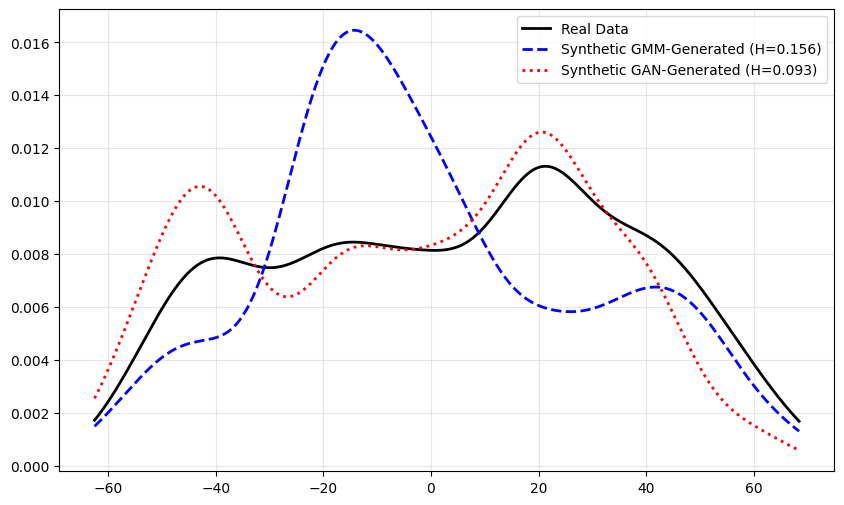

   -> Generando gráfico Dim 2...


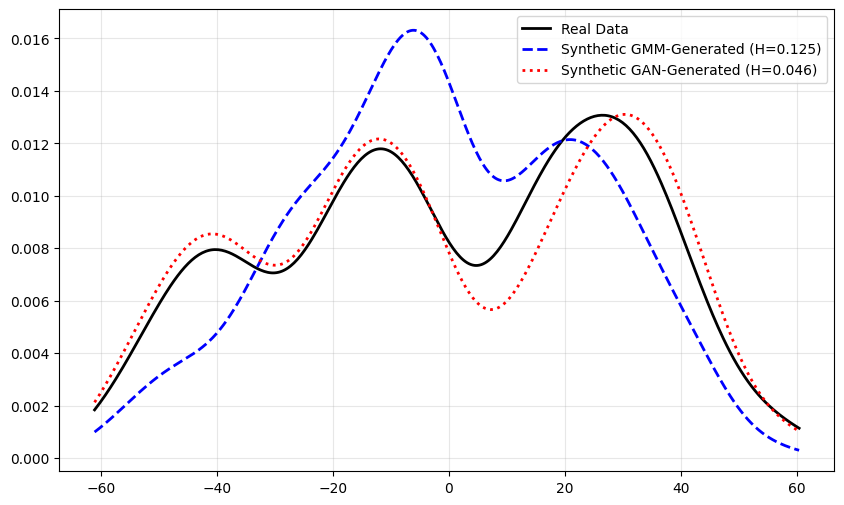


📏 Calculando Hellinger en espacio original (histogramdd)...
   Real vs GMM: 0.3965
   Real vs GAN: 0.3066

🎲 Configurando MMD con Kernel Global Unificado...
   ℹ️ Gamma Global calculado (Heurística de la Mediana): 1.844916e-03
   Ejecutando tests de permutación (1000 iteraciones)...
------------------------------------------------------------
RESULTADOS MMD (Kernel Fijo, Gamma=1.84e-03):
 >> Real vs GMM: Estadístico=0.026144 | p-value=0.0010
 >> Real vs GAN: Estadístico=0.013175 | p-value=0.0010
------------------------------------------------------------
Interpretación:
 - GMM es DIFERENTE a Real.
 - GAN es DIFERENTE a Real.


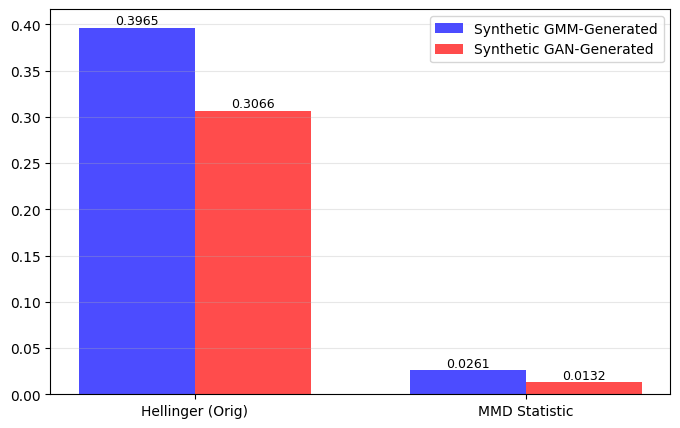


✅ Ejecución finalizada.


In [ ]:
import io
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import pairwise_distances
from sklearn.metrics.pairwise import rbf_kernel
from google.colab import files

# ----------------- Configuración -----------------
RANDOM_STATE = 42
TSNE_PERPLEXITY = 30
TSNE_N_ITER = 1000
BANDWIDTH_FACTOR = None
DEFAULT_N_EXPECTED_COLS = 10

OUT_DIM1_PNG = "kde_tsne_dim1_three.png"
OUT_DIM2_PNG = "kde_tsne_dim2_three.png"
OUT_HELLINGER_PNG = "hellinger_comparison.png"
OUT_MMD_PNG = "mmd_comparison.png"

# Params para Histogram/Hellinger
HIST_BINS = 8
HIST_PCA_DIMS = 4
MAX_HIST_DIMS = 4

# Params para MMD
MMD_SUBSAMPLE = 1051  # Cantidad de datos a usar para la prueba (por eficiencia)
N_PERMUTATIONS = 1000  # Número de permutaciones para el p-value

# Etiquetas
LABEL_REAL = "Real Data"
LABEL_GMM  = "Synthetic GMM-Generated"
LABEL_GAN  = "Synthetic GAN-Generated"
# -------------------------------------------------

# ----------------- 1. Carga de Datos (Tu función) -----------------
def upload_three_files_prompt():
    print("🔼 Sube los tres archivos CSV: primero el real, luego el sintético GMM y luego el sintético GAN.")
    uploaded = files.upload()
    while len(uploaded) < 3:
        print(f"Se detectó {len(uploaded)} archivo(s). Por favor sube los otros archivos (total 3).")
        more = files.upload()
        uploaded.update(more)
    return uploaded

def read_three_csvs_from_uploaded(uploaded):
    keys = list(uploaded.keys())
    # Asumimos el orden de carga: 0->Real, 1->GMM, 2->GAN
    fname_real = keys[0]
    fname_gmm  = keys[1]
    fname_gan  = keys[2]

    df_real = pd.read_csv(io.BytesIO(uploaded[fname_real]))
    df_gmm  = pd.read_csv(io.BytesIO(uploaded[fname_gmm]))
    df_gan  = pd.read_csv(io.BytesIO(uploaded[fname_gan]))
    return df_real, df_gmm, df_gan, fname_real, fname_gmm, fname_gan

# ----------------- 2. Funciones Auxiliares de Limpieza -----------------
def dropna_and_report(X, label):
    mask = ~np.isnan(X).any(axis=1)
    removed = X.shape[0] - mask.sum()
    if removed > 0:
        print(f"⚠️ Advertencia: se eliminaron {removed} filas con NaN en {label}.")
    return X[mask]

def ensure_numeric_matrix(df, n_cols):
    if df.shape[1] < n_cols:
        raise ValueError(f"Se esperaban al menos {n_cols} columnas, pero el archivo tiene {df.shape[1]}.")
    arr = df.iloc[:, :n_cols].values.astype(float)
    return arr

def adjust_perplexity(perplexity, n_samples):
    max_allowed = max(5, int(np.floor(n_samples / 3) - 1))
    if perplexity >= max_allowed:
        return max_allowed
    return perplexity

# ----------------- 3. Funciones Hellinger y KDE -----------------
def hellinger_from_densities(p, q, dx):
    p = np.maximum(p, 0.0)
    q = np.maximum(q, 0.0)
    h = (1.0 / np.sqrt(2.0)) * np.sqrt(np.sum((np.sqrt(p) - np.sqrt(q))**2) * dx)
    return float(h)

def hellinger_histogramdd(a, b, bins=HIST_BINS, use_pca_dims=HIST_PCA_DIMS):
    a = np.asarray(a)
    b = np.asarray(b)
    d = a.shape[1]

    # Si hay muchas dimensiones, reducir con PCA antes del histograma
    if d > MAX_HIST_DIMS:
        scaler = StandardScaler()
        combo = np.vstack([a, b])
        combo_s = scaler.fit_transform(combo)
        pca = PCA(n_components=use_pca_dims, random_state=RANDOM_STATE)
        combo_p = pca.fit_transform(combo_s)
        a2 = combo_p[:a.shape[0], :]
        b2 = combo_p[a.shape[0]:, :]
    else:
        a2, b2 = a.copy(), b.copy()

    mins = np.minimum(a2.min(axis=0), b2.min(axis=0))
    maxs = np.maximum(a2.max(axis=0), b2.max(axis=0))
    ranges = [(mins[i], maxs[i]) for i in range(a2.shape[1])]

    H_hist, _ = np.histogramdd(a2, bins=bins, range=ranges)
    G_hist, _ = np.histogramdd(b2, bins=bins, range=ranges)

    H_hist = H_hist.astype(float) / np.sum(H_hist)
    G_hist = G_hist.astype(float) / np.sum(G_hist)

    return hellinger_from_densities(H_hist.ravel(), G_hist.ravel(), dx=1.0)

# ----------------- 4. Funciones MMD y Prueba de Permutación -----------------
def calculate_mmd_squared(Kxx, Kyy, Kxy):
    """Calcula MMD^2 (estadístico V) dados los kernels."""
    m = Kxx.shape[0]
    n = Kyy.shape[0]
    return Kxx.sum() / (m * m) + Kyy.sum() / (n * n) - 2 * Kxy.sum() / (m * n)

def compute_global_gamma(X_list, subsample=1000, random_state=42):
    """
    Calcula un gamma (ancho de banda RBF) unificado usando la heurística de la mediana
    sobre una muestra combinada de TODOS los datasets.
    Esto asegura que el RKHS sea el mismo para todas las comparaciones.
    """
    np.random.seed(random_state)
    # Concatenar todos los datos disponibles
    X_comb = np.vstack(X_list)

    # Subsampling para eficiencia en el cálculo de distancias
    if X_comb.shape[0] > subsample:
        idx = np.random.choice(X_comb.shape[0], subsample, replace=False)
        X_comb = X_comb[idx]

    # Heurística de la mediana
    D = pairwise_distances(X_comb, metric='euclidean')
    dvals = D[np.triu_indices_from(D, k=1)]
    med = np.median(dvals)
    if med <= 0: med = 1.0

    gamma = 1.0 / (2.0 * (med**2) + 1e-8)
    return gamma

def mmd_permutation_test(X, Y, gamma, n_perm=500, subsample=1000, random_state=42):
    """
    Realiza la prueba de permutación usando un GAMMA FIJO.
    """
    np.random.seed(random_state)
    X = np.asarray(X)
    Y = np.asarray(Y)

    # Subsample para el test
    if X.shape[0] > subsample:
        idx_x = np.random.choice(X.shape[0], subsample, replace=False)
        X = X[idx_x]
    if Y.shape[0] > subsample:
        idx_y = np.random.choice(Y.shape[0], subsample, replace=False)
        Y = Y[idx_y]

    n_x = X.shape[0]
    combined_data = np.vstack([X, Y])

    # Precomputar Kernel Matrix con el gamma fijo
    K_full = rbf_kernel(combined_data, combined_data, gamma=gamma)

    # MMD Observado
    Kxx = K_full[:n_x, :n_x]
    Kyy = K_full[n_x:, n_x:]
    Kxy = K_full[:n_x, n_x:]
    mmd_obs = calculate_mmd_squared(Kxx, Kyy, Kxy)

    # Permutaciones
    count_greater = 0
    indices = np.arange(combined_data.shape[0])

    for i in range(n_perm):
        np.random.shuffle(indices)
        idx_a = indices[:n_x]
        idx_b = indices[n_x:]

        Kxx_p = K_full[np.ix_(idx_a, idx_a)]
        Kyy_p = K_full[np.ix_(idx_b, idx_b)]
        Kxy_p = K_full[np.ix_(idx_a, idx_b)]

        mmd_perm = calculate_mmd_squared(Kxx_p, Kyy_p, Kxy_p)
        if mmd_perm >= mmd_obs:
            count_greater += 1

    p_value = (count_greater + 1) / (n_perm + 1)
    return float(mmd_obs), p_value

# =============================================================================
#                                EJECUCIÓN PRINCIPAL
# =============================================================================

print("=== Análisis Completo: t-SNE, Hellinger y MMD Test ===")

# 1. Cargar Archivos
uploaded = upload_three_files_prompt()
df_real, df_gmm, df_gan, fname_real, fname_gmm, fname_gan = read_three_csvs_from_uploaded(uploaded)

print(f"\n📂 Archivos:\n - Real: {fname_real} {df_real.shape}\n - GMM:  {fname_gmm} {df_gmm.shape}\n - GAN:  {fname_gan} {df_gan.shape}")

# 2. Selección de Columnas
try:
    user_input = input(f"\nIntroduce el número de columnas a usar (Enter para {DEFAULT_N_EXPECTED_COLS}): ").strip()
    n_cols = int(user_input) if user_input else DEFAULT_N_EXPECTED_COLS
except:
    n_cols = DEFAULT_N_EXPECTED_COLS
print(f"Using first {n_cols} columns.")

X_real = ensure_numeric_matrix(df_real, n_cols)
X_gmm  = ensure_numeric_matrix(df_gmm, n_cols)
X_gan  = ensure_numeric_matrix(df_gan, n_cols)

X_real = dropna_and_report(X_real, LABEL_REAL)
X_gmm  = dropna_and_report(X_gmm, LABEL_GMM)
X_gan  = dropna_and_report(X_gan, LABEL_GAN)

# 3. t-SNE y KDE Plots
print("\n🔬 Calculando t-SNE (Proyección 2D)...")
X_comb = np.vstack([X_real, X_gmm, X_gan])
X_comb_scaled = StandardScaler().fit_transform(X_comb)

n_total = X_comb_scaled.shape[0]
perp = adjust_perplexity(TSNE_PERPLEXITY, n_total)
eff_iter = max(250, TSNE_N_ITER)

tsne = TSNE(n_components=2, perplexity=perp, max_iter=eff_iter, random_state=RANDOM_STATE, init='pca')
X_tsne = tsne.fit_transform(X_comb_scaled)

# Separar t-SNE
n_r = X_real.shape[0]
n_g = X_gmm.shape[0]
tsne_real = X_tsne[:n_r, :]
tsne_gmm  = X_tsne[n_r : n_r+n_g, :]
tsne_gan  = X_tsne[n_r+n_g :, :]

# Graficar KDE por dimensión t-SNE
def plot_kde_dimension(dim_idx, data_r, data_gmm, data_gan, out_name):
    # Datos de la dimensión específica
    xr = data_r[:, dim_idx]
    xg = data_gmm[:, dim_idx]
    xn = data_gan[:, dim_idx]

    # Grid común
    comb = np.hstack([xr, xg, xn])
    grid = np.linspace(comb.min()-1, comb.max()+1, 400)

    # KDEs
    kde_r = gaussian_kde(xr); kde_g = gaussian_kde(xg); kde_n = gaussian_kde(xn)
    if BANDWIDTH_FACTOR:
        for k in [kde_r, kde_g, kde_n]: k.set_bandwidth(k.factor * BANDWIDTH_FACTOR)

    y_r = kde_r(grid); y_g = kde_g(grid); y_n = kde_n(grid)

    # Hellinger local (en esta dimensión t-SNE)
    h_gmm = hellinger_from_densities(y_r, y_g, grid[1]-grid[0])
    h_gan = hellinger_from_densities(y_r, y_n, grid[1]-grid[0])

    plt.figure(figsize=(10, 6))
    plt.plot(grid, y_r, label=LABEL_REAL, lw=2, color='black')
    plt.plot(grid, y_g, label=f"{LABEL_GMM} (H={h_gmm:.3f})", ls='--', lw=2, color='blue')
    plt.plot(grid, y_n, label=f"{LABEL_GAN} (H={h_gan:.3f})", ls=':', lw=2, color='red')
    #plt.title(f"t-SNE Dimension {dim_idx+1} Density")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.savefig(out_name, dpi=300)
    plt.show()
    return h_gmm, h_gan

print("   -> Generando gráfico Dim 1...")
h1_gmm, h1_gan = plot_kde_dimension(0, tsne_real, tsne_gmm, tsne_gan, OUT_DIM1_PNG)
print("   -> Generando gráfico Dim 2...")
h2_gmm, h2_gan = plot_kde_dimension(1, tsne_real, tsne_gmm, tsne_gan, OUT_DIM2_PNG)

# 4. Hellinger Espacio Original
print("\n📏 Calculando Hellinger en espacio original (histogramdd)...")
h_orig_gmm = hellinger_histogramdd(X_real, X_gmm)
h_orig_gan = hellinger_histogramdd(X_real, X_gan)
print(f"   Real vs GMM: {h_orig_gmm:.4f}")
print(f"   Real vs GAN: {h_orig_gan:.4f}")

# 5. MMD + Permutation Test (Con Gamma Global)
print(f"\n🎲 Configurando MMD con Kernel Global Unificado...")

# A. Calcular Gamma Global usando los 3 datasets
# Esto hace que las distancias sean estrictamente comparables
global_gamma = compute_global_gamma([X_real, X_gmm, X_gan], subsample=2000)
print(f"   ℹ️ Gamma Global calculado (Heurística de la Mediana): {global_gamma:.6e}")

# B. Ejecutar Tests
print(f"   Ejecutando tests de permutación ({N_PERMUTATIONS} iteraciones)...")

# Nota: Pasamos global_gamma a ambas funciones
mmd_gmm, p_gmm = mmd_permutation_test(X_real, X_gmm, gamma=global_gamma, n_perm=N_PERMUTATIONS, subsample=MMD_SUBSAMPLE)
mmd_gan, p_gan = mmd_permutation_test(X_real, X_gan, gamma=global_gamma, n_perm=N_PERMUTATIONS, subsample=MMD_SUBSAMPLE)

print("-" * 60)
print(f"RESULTADOS MMD (Kernel Fijo, Gamma={global_gamma:.2e}):")
print(f" >> Real vs GMM: Estadístico={mmd_gmm:.6f} | p-value={p_gmm:.4f}")
print(f" >> Real vs GAN: Estadístico={mmd_gan:.6f} | p-value={p_gan:.4f}")
print("-" * 60)

# Interpretación
alpha = 0.05
msg_gmm = "DIFERENTE" if p_gmm < alpha else "SIMILAR"
msg_gan = "DIFERENTE" if p_gan < alpha else "SIMILAR"
print(f"Interpretación:\n - GMM es {msg_gmm} a Real.\n - GAN es {msg_gan} a Real.")

# 6. Gráfico de Barras Resumen
metrics = ['Hellinger (Orig)', 'MMD Statistic']
vals_gmm = [h_orig_gmm, mmd_gmm]
vals_gan = [h_orig_gan, mmd_gan]

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, vals_gmm, width, label=LABEL_GMM, color='blue', alpha=0.7)
plt.bar(x + width/2, vals_gan, width, label=LABEL_GAN, color='red', alpha=0.7)
plt.xticks(x, metrics)
#plt.title("Comparación de Métricas: Hellinger vs MMD")
plt.legend()
plt.grid(axis='y', alpha=0.3)

# Anotaciones
for i, v in enumerate(vals_gmm):
    plt.text(i - width/2, v, f"{v:.4f}", ha='center', va='bottom', fontsize=9)
for i, v in enumerate(vals_gan):
    plt.text(i + width/2, v, f"{v:.4f}", ha='center', va='bottom', fontsize=9)

plt.savefig(OUT_MMD_PNG, dpi=300)
plt.show()

print("\n✅ Ejecución finalizada.")

# **DATA AUGMENTATION ON REGRESSION**
Comparison of XGBOOST Models (with and without data augmentation)


[Modelo 1 (Original)] Iniciando procesamiento con 5252 muestras...
[Modelo 1 (Original)] Completado. Promedio R2: 0.4566 | Mejor R2 (Fold 5): 0.5053

[Modelo 2 (Con GAN)] Iniciando procesamiento con 8252 muestras...
[Modelo 2 (Con GAN)] Completado. Promedio R2: 0.5037 | Mejor R2 (Fold 4): 0.5318

RESUMEN COMPARATIVO DE MÉTRICAS
          Métrica  Modelo 1 (Original)  Modelo 2 (Aumentado)
    R2 (Promedio)             0.456626              0.503690
  RMSE (Promedio)             2.064149              1.917607
  MAPE (Promedio)             0.116219              0.106371
  R2 (Mejor Fold)             0.505295              0.531796
RMSE (Mejor Fold)             2.003001              1.867031
MAPE (Mejor Fold)             0.115883              0.103695


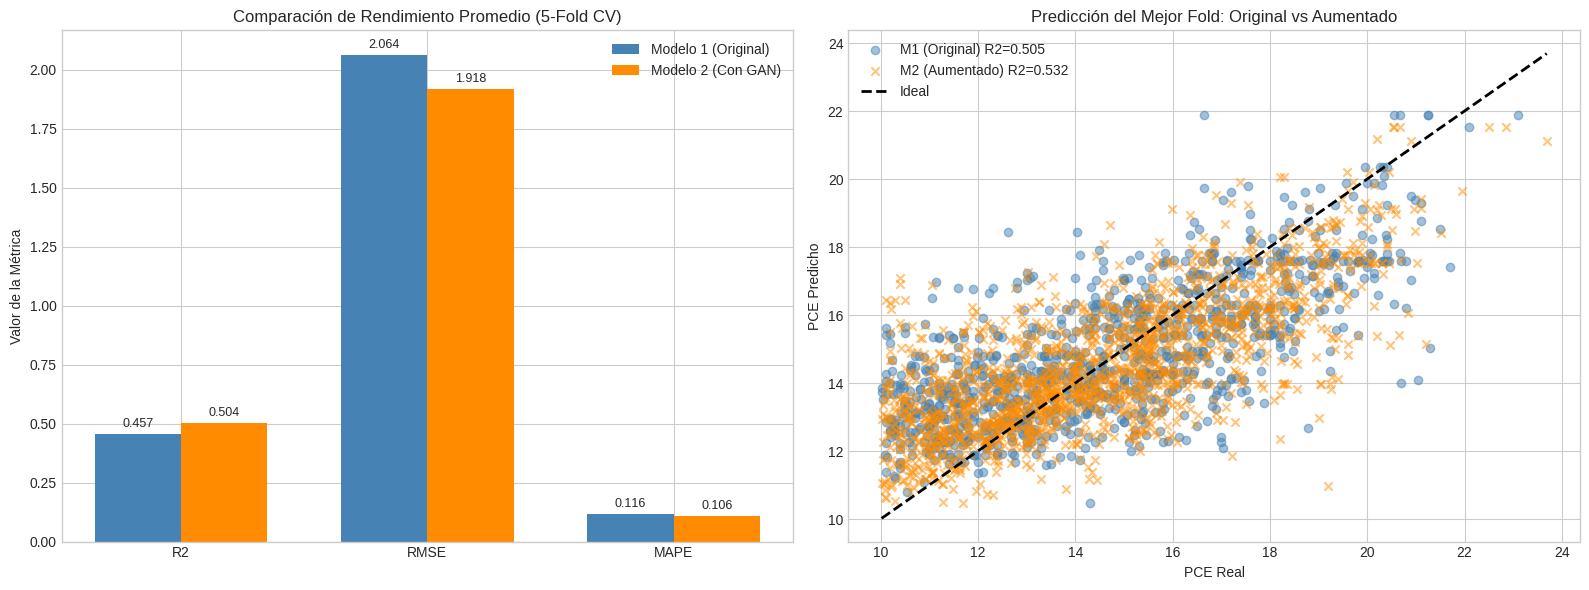


Proceso finalizado con éxito.


In [ ]:
# ==============================================================================
# SCRIPT DE ENTRENAMIENTO Y COMPARACIÓN DE MODELOS XGBOOST (CON Y SIN AUMENTO DE DATOS)
# ==============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import joblib
import matplotlib.pyplot as plt
import os

# Configuración de estilo para gráficas formales
plt.style.use('seaborn-v0_8-whitegrid')

# ==============================================================================
# DEFINICIÓN DE PARÁMETROS DEL MODELO (Idénticos a la referencia)
# ==============================================================================
XGB_PARAMS = {
    'objective': 'reg:squarederror',
    'n_estimators': 1000,
    'max_depth': 9,
    'learning_rate': 0.01,
    'subsample': 0.6,
    'colsample_bytree': 0.8,
    'gamma': 0,
    'n_jobs': -1,
    'random_state': 42
}

N_FOLDS = 5

# ==============================================================================
# FUNCIÓN AUXILIAR: ENTRENAMIENTO Y EVALUACIÓN MEDIANTE K-FOLD
# ==============================================================================
def ejecutar_kfold_xgboost(nombre_modelo, df_datos, params, n_folds=10):
    """
    Ejecuta validación cruzada K-Fold sobre un DataFrame dado.
    Retorna métricas promedio, métricas del mejor fold y el mejor modelo.
    """
    print(f"\n[{nombre_modelo}] Iniciando procesamiento con {df_datos.shape[0]} muestras...")

    # Separar X e y (Asumiendo que la variable objetivo es la última columna)
    X = df_datos.iloc[:, :-1].values
    y = df_datos.iloc[:, -1].values

    # Estandarización
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Inicialización de KFold
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    # Almacenamiento de métricas
    resultados_r2 = []
    resultados_rmse = []
    resultados_mape = []

    best_r2 = -float('inf')
    best_model_obj = None
    best_fold_idx = -1
    best_y_test = None
    best_y_pred = None
    best_scaler = scaler # Guardamos el scaler ajustado a todos los datos para consistencia

    fold = 1
    for train_index, test_index in kf.split(X_scaled):
        # Separar datos
        X_train, X_test = X_scaled[train_index], X_scaled[test_index]
        y_train, y_test = y[train_index], y[test_index]

        # Instanciar Modelo
        model = xgb.XGBRegressor(**params)

        # Entrenar
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            verbose=False
        )

        # Predecir
        y_pred = model.predict(X_test)

        # Calcular Métricas
        r2 = r2_score(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        mape = mean_absolute_percentage_error(y_test, y_pred)

        resultados_r2.append(r2)
        resultados_rmse.append(rmse)
        resultados_mape.append(mape)

        # Verificar si es el mejor fold
        if r2 > best_r2:
            best_r2 = r2
            best_model_obj = model
            best_fold_idx = fold
            best_y_test = y_test
            best_y_pred = y_pred

        fold += 1

    # Cálculo de promedios
    avg_metrics = {
        'R2': np.mean(resultados_r2),
        'RMSE': np.mean(resultados_rmse),
        'MAPE': np.mean(resultados_mape)
    }

    best_metrics = {
        'Fold': best_fold_idx,
        'R2': best_r2,
        'RMSE': resultados_rmse[best_fold_idx-1],
        'MAPE': resultados_mape[best_fold_idx-1]
    }

    print(f"[{nombre_modelo}] Completado. Promedio R2: {avg_metrics['R2']:.4f} | Mejor R2 (Fold {best_fold_idx}): {best_r2:.4f}")

    return {
        'model_name': nombre_modelo,
        'avg_metrics': avg_metrics,
        'best_metrics': best_metrics,
        'best_model': best_model_obj,
        'best_scaler': best_scaler,
        'best_data': (best_y_test, best_y_pred)
    }

# ==============================================================================
# 1. CARGA Y PREPARACIÓN DE DATOS
# ==============================================================================
files_required = ['Data_train.csv', 'Data_test.csv', 'generated_perovskite_GAN3.csv']
for f in files_required:
    if not os.path.exists(f):
        raise FileNotFoundError(f"Error crítico: No se encuentra el archivo {f}")

# Carga de archivos
df_train = pd.read_csv('Data_train.csv')
df_test = pd.read_csv('Data_test.csv')
df_gan = pd.read_csv('generated_perovskite_x3000.csv')

# --- PREPARACIÓN MODELO 1: Data_train + Data_test ---
df_m1 = pd.concat([df_train, df_test], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# --- PREPARACIÓN MODELO 2: Data_train + GAN + Data_test ---
df_m2 = pd.concat([df_train, df_gan, df_test], axis=0).sample(frac=1, random_state=42).reset_index(drop=True)

# ==============================================================================
# 2. EJECUCIÓN DE LOS MODELOS
# ==============================================================================

# Ejecutar Modelo 1 (Sin datos sintéticos)
results_m1 = ejecutar_kfold_xgboost("Modelo 1 (Original)", df_m1, XGB_PARAMS, N_FOLDS)

# Ejecutar Modelo 2 (Con datos sintéticos/Aumento)
results_m2 = ejecutar_kfold_xgboost("Modelo 2 (Con GAN)", df_m2, XGB_PARAMS, N_FOLDS)

# Guardar los mejores modelos
joblib.dump(results_m1['best_model'], 'Best_Model_Original.joblib')
joblib.dump(results_m2['best_model'], 'Best_Model_Augmented.joblib')

# ==============================================================================
# 3. REPORTE DE MÉTRICAS
# ==============================================================================
print("\n" + "="*60)
print("RESUMEN COMPARATIVO DE MÉTRICAS")
print("="*60)

# Tabla de Promedios
metrics_df = pd.DataFrame({
    'Métrica': ['R2 (Promedio)', 'RMSE (Promedio)', 'MAPE (Promedio)',
                'R2 (Mejor Fold)', 'RMSE (Mejor Fold)', 'MAPE (Mejor Fold)'],
    'Modelo 1 (Original)': [
        results_m1['avg_metrics']['R2'], results_m1['avg_metrics']['RMSE'], results_m1['avg_metrics']['MAPE'],
        results_m1['best_metrics']['R2'], results_m1['best_metrics']['RMSE'], results_m1['best_metrics']['MAPE']
    ],
    'Modelo 2 (Aumentado)': [
        results_m2['avg_metrics']['R2'], results_m2['avg_metrics']['RMSE'], results_m2['avg_metrics']['MAPE'],
        results_m2['best_metrics']['R2'], results_m2['best_metrics']['RMSE'], results_m2['best_metrics']['MAPE']
    ]
})

print(metrics_df.to_string(index=False))

# ==============================================================================
# 4. GRAFICACIÓN
# ==============================================================================

# Gráfica 1: Comparación de Métricas Promedio (Barras)
labels = ['R2', 'RMSE', 'MAPE']
m1_means = [results_m1['avg_metrics']['R2'], results_m1['avg_metrics']['RMSE'], results_m1['avg_metrics']['MAPE']]
m2_means = [results_m2['avg_metrics']['R2'], results_m2['avg_metrics']['RMSE'], results_m2['avg_metrics']['MAPE']]

x = np.arange(len(labels))
width = 0.35

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Barras de métricas promedio
rects1 = axs[0].bar(x - width/2, m1_means, width, label='Modelo 1 (Original)', color='steelblue')
rects2 = axs[0].bar(x + width/2, m2_means, width, label='Modelo 2 (Con GAN)', color='darkorange')

axs[0].set_ylabel('Valor de la Métrica')
axs[0].set_title('Comparación de Rendimiento Promedio (5-Fold CV)')
axs[0].set_xticks(x)
axs[0].set_xticklabels(labels)
axs[0].legend()

# Etiquetas de valor sobre las barras
def autolabel(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1, axs[0])
autolabel(rects2, axs[0])

# Subplot 2: Dispersión de los Mejores Folds (Predicho vs Real)
y_real_m1, y_pred_m1 = results_m1['best_data']
y_real_m2, y_pred_m2 = results_m2['best_data']

axs[1].scatter(y_real_m1, y_pred_m1, alpha=0.5, label=f'M1 (Original) R2={results_m1["best_metrics"]["R2"]:.3f}', color='steelblue')
axs[1].scatter(y_real_m2, y_pred_m2, alpha=0.5, label=f'M2 (Aumentado) R2={results_m2["best_metrics"]["R2"]:.3f}', color='darkorange', marker='x')

# Línea ideal
max_val = max(np.max(y_real_m1), np.max(y_real_m2))
min_val = min(np.min(y_real_m1), np.min(y_real_m2))
axs[1].plot([min_val, max_val], [min_val, max_val], 'k--', lw=2, label='Ideal')

axs[1].set_xlabel('PCE Real')
axs[1].set_ylabel('PCE Predicho')
axs[1].set_title('Predicción del Mejor Fold: Original vs Aumentado')
axs[1].legend()

plt.tight_layout()
plt.show()

print("\nProceso finalizado con éxito.")

# **VIRTUAL LABORATORY TRAINING**
Calibrated with XGBoost

In [ ]:
# =============================================================================
# ENTRENAMIENTO LABORATORIO VIRTUAL (XGBOOST) - VERSIÓN UNIVERSAL
# -----------------------------------------------------------------------------
# Este script entrena un nuevo modelo predictor (Judge) usando TODOS los datos
# disponibles (Data_train.csv, Data_test.csv, etc.) y aplicando One-Hot Encoding.
# Esto asegura compatibilidad total con la cGAN Universal.
# =============================================================================

import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.model_selection import KFold, RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
import joblib
import matplotlib.pyplot as plt
import os
import sys

# --- CONFIGURACIÓN ---
N_FOLDS = 10
RANDOM_SEED = 42

def load_universal_data():
    """
    Carga todos los archivos CSV de datos (Train/Test) y aplica el mismo
    preprocesamiento que la cGAN Universal (One-Hot Encoding).
    """
    print("🔄 Buscando archivos de datos 'Data_*.csv'...")
    archivos = [f for f in os.listdir('.') if f.startswith('Data_') and f.endswith('.csv')]

    dfs = []
    if not archivos:
        print("❌ No se encontraron archivos Data_*.csv.")
        return None, None

    for f in archivos:
        print(f"   📄 Cargando: {f}")
        dfs.append(pd.read_csv(f))

    df = pd.concat(dfs, ignore_index=True)
    print(f"📊 Dataset combinado: {df.shape}")

    # --- PREPROCESAMIENTO UNIVERSAL ---

    # 1. Separar Target (Asumimos última columna es PCE)
    target_col = df.columns[-1]
    y = df[target_col].values
    X_df = df.iloc[:, :-1]

    # 2. Eliminar constantes (si existen)
    cols_const = [c for c in X_df.columns if X_df[c].nunique() <= 1]
    if cols_const:
        print(f"🧹 Eliminando columnas constantes: {cols_const}")
        X_df = X_df.drop(columns=cols_const)

    # 3. One-Hot Encoding (Crucial para Multi-Perovskita)
    # Convierte texto a columnas numéricas (Type_A, Type_B...)
    X_encoded = pd.get_dummies(X_df, drop_first=True)

    feature_names = X_encoded.columns.tolist()
    X = X_encoded.values

    print(f"✅ Preprocesamiento listo.")
    print(f"   Variables finales ({len(feature_names)}): {feature_names}")

    return X, y, feature_names

# --- BLOQUE PRINCIPAL ---

if __name__ == "__main__":
    X, y, features = load_universal_data()

    if X is None:
        sys.exit("Deteniendo ejecución por falta de datos.")

    # 1. Escalar Datos
    print("\n⚖️  Escalando datos...")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    # Guardamos el scaler inmediatamente (necesario para validación futura)
    # Nota: Guardamos features también para verificar alineación luego si es necesario
    scaler_info = {'scaler': scaler, 'features': features}
    joblib.dump(scaler, 'Scaler_Universal.joblib') # Guardamos solo objeto scaler para compatibilidad simple
    # Opcional: Guardar info de columnas para debug
    joblib.dump(features, 'Universal_Columns.pkl')

    print("✅ Scaler guardado como 'Scaler_Universal.joblib'")

    # 2. Configuración XGBoost (Optimizado)
    print("\n🚀 Iniciando entrenamiento XGBoost Universal...")

    # Usamos parámetros robustos (puedes descomentar el RandomizedSearch si quieres re-optimizar)
    model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=1000,
        learning_rate=0.05,
        max_depth=7,
        subsample=0.7,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=RANDOM_SEED
    )

    # 3. Validación Cruzada (K-Fold) para asegurar calidad
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

    r2_scores = []
    rmse_scores = []

    print(f"   Ejecutando {N_FOLDS}-Fold Cross Validation...")

    # Entrenamos en todo el dataset pero validamos para reporte
    # Para el modelo final, entrenaremos con TODOS los datos.

    fold = 1
    for train_idx, val_idx in kf.split(X_scaled):
        X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]

        model.fit(X_train, y_train, verbose=False)
        preds = model.predict(X_val)

        r2 = r2_score(y_val, preds)
        rmse = np.sqrt(mean_squared_error(y_val, preds))

        r2_scores.append(r2)
        rmse_scores.append(rmse)
        # print(f"   Fold {fold}: R2={r2:.3f}")
        fold += 1

    print(f"\n📈 Resultados Promedio:")
    print(f"   R2 Promedio: {np.mean(r2_scores):.4f} (±{np.std(r2_scores):.3f})")
    print(f"   RMSE Promedio: {np.mean(rmse_scores):.4f}")

    # 4. Entrenamiento Final y Guardado
    print("\n💾 Entrenando modelo final con el 100% de los datos...")
    final_model = xgb.XGBRegressor(
        objective='reg:squarederror',
        n_estimators=1200, # Un poco más para el final
        learning_rate=0.05,
        max_depth=7,
        subsample=0.7,
        colsample_bytree=0.8,
        n_jobs=-1,
        random_state=RANDOM_SEED
    )

    final_model.fit(X_scaled, y)

    joblib.dump(final_model, 'Lab_Virtual_Universal.joblib')
    print("✅ Modelo final guardado como 'Lab_Virtual_Universal.joblib'")

    print("\n⚠️ IMPORTANTE PARA VALIDACIÓN:")
    print("En tu script de validación (montecarlo_validation_zip.py), actualiza:")
    print("MODEL_PATH = 'Lab_Virtual_Universal.joblib'")
    print("SCALER_PATH = 'Scaler_Universal.joblib'")

🔄 Buscando archivos de datos 'Data_*.csv'...
   📄 Cargando: Data_test.csv
   📄 Cargando: Data_train.csv
📊 Dataset combinado: (5252, 10)
✅ Preprocesamiento listo.
   Variables finales (9): ['0', '1', '2', '3', '4', '5', '6', '7', '8']

⚖️  Escalando datos...
✅ Scaler guardado como 'Scaler_Universal.joblib'

🚀 Iniciando entrenamiento XGBoost Universal...
   Ejecutando 10-Fold Cross Validation...

📈 Resultados Promedio:
   R2 Promedio: 0.4515 (±0.041)
   RMSE Promedio: 2.0733

💾 Entrenando modelo final con el 100% de los datos...
✅ Modelo final guardado como 'Lab_Virtual_Universal.joblib'

⚠️ IMPORTANTE PARA VALIDACIÓN:
En tu script de validación (montecarlo_validation_zip.py), actualiza:
MODEL_PATH = 'Lab_Virtual_Universal.joblib'
SCALER_PATH = 'Scaler_Universal.joblib'


# **TARGETED INVERSE DESIGN OF SYNTHESIS PARAMETERS**
Weighted AC-GAN training

In [ ]:
# DATOS PROFESOR-*-
"""
SCRIPT MEJORADO: AC-GAN CON PONDERACIÓN DE RAREZA (Weighted AC-GAN)
-------------------------------------------------------------------
Estrategia para corregir el sesgo hacia la media:
1. Elimina columnas constantes (ruido).
2. Aplica 'Inverse Frequency Weighting': Penaliza mucho más al modelo
   si falla en predecir valores raros (PCE muy alto o muy bajo).
"""

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import MinMaxScaler
from google.colab import files
import io
import joblib
import os

# --- Configuración ---
EPOCHS = 5000           # Más épocas necesarias para aprender los casos raros
BATCH_SIZE = 64
LR = 0.0002
LATENT_DIM = 128
LAMBDA_AUX = 150        # Aumentamos el peso de la regresión
# Nota: FEATURE_DIM se calculará dinámicamente al cargar los datos

# --- Arquitectura (AC-GAN) ---

class ConditionalGenerator(nn.Module):
    def __init__(self, latent_dim, feature_dim, condition_dim=1):
        super(ConditionalGenerator, self).__init__()
        input_dim = latent_dim + condition_dim

        self.model = nn.Sequential(
            nn.Linear(input_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, feature_dim),
            nn.Tanh()
        )

    def forward(self, z, condition):
        x = torch.cat([z, condition], dim=1)
        return self.model(x)

class AuxiliaryDiscriminator(nn.Module):
    def __init__(self, feature_dim):
        super(AuxiliaryDiscriminator, self).__init__()

        self.features = nn.Sequential(
            nn.Linear(feature_dim, 1024),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4), # Más dropout para evitar memorización
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2),
            nn.Dropout(0.4)
        )

        # Cabeza Real/Fake
        self.validity_layer = nn.Sequential(
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

        # Cabeza Regresora (PCE)
        self.auxiliary_layer = nn.Sequential(
            nn.Linear(256, 1)
        )

    def forward(self, x):
        feat = self.features(x)
        validity = self.validity_layer(feat)
        label_pred = self.auxiliary_layer(feat)
        return validity, label_pred

# --- Funciones de Utilidad ---

def calculate_rare_weights(pce_tensor, bins=10):
    """
    Calcula pesos para cada muestra basados en la rareza de su PCE.
    PCE raros -> Peso Alto. PCE comunes -> Peso Bajo.
    """
    # Convertir a numpy para histograma
    pce_np = pce_tensor.cpu().numpy().flatten()

    # Calcular histograma de densidad
    hist, bin_edges = np.histogram(pce_np, bins=bins, density=True)

    # Asignar peso inverso a la densidad (1 / probabilidad)
    # Agregamos epsilon para evitar división por cero
    weights = []
    epsilon = 1e-6

    for val in pce_np:
        # Encontrar en qué bin cae el valor
        bin_idx = np.digitize(val, bin_edges) - 1
        bin_idx = min(max(bin_idx, 0), bins-1) # Clip por seguridad

        density = hist[bin_idx]
        weight = 1.0 / (density + epsilon)
        weights.append(weight)

    weights = np.array(weights)

    # Normalizar pesos para que la media sea 1.0 (para no explotar el gradiente)
    weights = weights / weights.mean()

    return torch.FloatTensor(weights).reshape(-1, 1)

def load_smart_data():
    archivos = ['Data_train.csv', 'Data_test.csv']
    dfs = []

    print("Iniciando carga inteligente de datos...")
    for archivo in archivos:
        if os.path.exists(archivo):
            dfs.append(pd.read_csv(archivo))

    if not dfs:
        print("❌ Error: No se encontraron archivos CSV.")
        return None, None, None, None

    df = pd.concat(dfs, ignore_index=True)
    print(f"📊 Datos totales: {df.shape}")

    # 1. ELIMINACIÓN DE COLUMNAS CONSTANTES
    # Identificamos columnas donde solo hay 1 valor único
    cols_to_drop = [c for c in df.columns if df[c].nunique() <= 1]

    if cols_to_drop:
        print(f"🧹 Eliminando {len(cols_to_drop)} columnas constantes (ruido): {cols_to_drop}")
        df = df.drop(columns=cols_to_drop)

    feature_cols = df.columns[:-1].tolist() # Todas menos la última
    target_col = df.columns[-1]             # La última es PCE

    print(f"✅ Variables finales ({len(feature_cols)}): {feature_cols}")
    print(f"🎯 Variable objetivo: {target_col}")

    # 2. Escalado
    data_x = df[feature_cols].values.astype(np.float32)
    data_y = df[[target_col]].values.astype(np.float32)

    # Scaler X (Features)
    scaler_x = MinMaxScaler(feature_range=(-1, 1))
    x_scaled = scaler_x.fit_transform(data_x)

    # Scaler Y (Target) - Importante escalar el target también para la red
    # Aunque a veces se usa 0-1, usaremos -1 a 1 para consistencia con Tanh si fuera necesario,
    # pero para regresión lineal, el rango 0-1 o estandarización suele ser mejor.
    # Aquí mantenemos la lógica cruda, pero pasamos el target tal cual al dataset
    # para calcular los pesos correctamente, luego la red intentará predecir ese valor.
    # NOTA: Para estabilidad, normalizaremos el PCE entre 0 y 1 internamente
    scaler_y = MinMaxScaler(feature_range=(0, 1))
    y_scaled = scaler_y.fit_transform(data_y)

    # Concatenamos para el TensorDataset: [X_scaled, Y_scaled]
    data_combined = np.hstack((x_scaled, y_scaled))

    dataset = TensorDataset(torch.FloatTensor(data_combined))
    dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

    return dataloader, scaler_x, scaler_y, feature_cols

def train(dataloader, feature_dim):
    # Inicialización
    generator = ConditionalGenerator(LATENT_DIM, feature_dim)
    discriminator = AuxiliaryDiscriminator(feature_dim)

    opt_g = torch.optim.Adam(generator.parameters(), lr=LR, betas=(0.5, 0.999))
    opt_d = torch.optim.Adam(discriminator.parameters(), lr=LR, betas=(0.5, 0.999))

    adversarial_loss = nn.BCELoss()
    # Usaremos MSE pero ponderado manualmente en el loop

    print(f"🚀 Entrenando AC-GAN Ponderada con {feature_dim} variables...")

    for epoch in range(EPOCHS):
        for i, (batch,) in enumerate(dataloader):

            real_features = batch[:, :-1]
            real_condition = batch[:, -1:] # PCE normalizado (0 a 1)
            batch_size = real_features.size(0)

            # CÁLCULO DE PESOS DE IMPORTANCIA
            # Calculamos qué tan raro es este lote de PCEs
            # (Movemos a CPU para numpy, luego a GPU si usas CUDA)
            weights = calculate_rare_weights(real_condition)

            # Etiquetas
            valid = torch.ones(batch_size, 1) * 0.95
            fake = torch.zeros(batch_size, 1) + 0.05

            # ---------------------
            #  Entrenar Discriminador
            # ---------------------
            opt_d.zero_grad()

            # Real
            d_pred_real, d_pred_pce_real = discriminator(real_features)
            d_loss_real_adv = adversarial_loss(d_pred_real, valid)

            # Loss Auxiliar Ponderada (Real)
            # MSE manual: mean(weights * (pred - target)^2)
            loss_aux_real = torch.mean(weights * (d_pred_pce_real - real_condition) ** 2)

            # Fake
            z = torch.randn(batch_size, LATENT_DIM)
            fake_features = generator(z, real_condition)
            d_pred_fake, _ = discriminator(fake_features.detach())
            d_loss_fake_adv = adversarial_loss(d_pred_fake, fake)

            d_loss = (d_loss_real_adv + d_loss_fake_adv) / 2 + (LAMBDA_AUX * loss_aux_real)
            d_loss.backward()
            opt_d.step()

            # -----------------
            #  Entrenar Generador
            # -----------------
            opt_g.zero_grad()

            # El generador intenta engañar al discriminador
            g_pred_validity, g_pred_pce = discriminator(fake_features)

            g_loss_adv = adversarial_loss(g_pred_validity, torch.ones(batch_size, 1))

            # El generador debe acertar al PCE objetivo (Ponderado también)
            # Si falla en un PCE raro, el castigo es mayor
            loss_aux_gen = torch.mean(weights * (g_pred_pce - real_condition) ** 2)

            g_loss = g_loss_adv + (LAMBDA_AUX * loss_aux_gen)
            g_loss.backward()
            opt_g.step()

        if (epoch + 1) % 500 == 0:
            print(f"[Epoch {epoch+1}] D Loss: {d_loss.item():.4f} | G Aux Loss (PCE Error): {loss_aux_gen.item():.6f}")

    return generator

# --- Ejecución ---

if __name__ == "__main__":
    dataloader, scaler_x, scaler_y, cols = load_smart_data()

    if dataloader:
        # Determinamos dimensiones dinámicamente
        feat_dim = len(cols)

        trained_gen = train(dataloader, feat_dim)

        print("\n💾 Guardando modelo PONDERADO...")
        torch.save(trained_gen.state_dict(), 'cgan_weighted_gen.pth')

        # Guardamos ambos scalers
        meta_data = {
            'scaler_x': scaler_x,
            'scaler_y': scaler_y, # Necesario para des-normalizar el PCE al generar
            'columns': cols
        }
        joblib.dump(meta_data, 'cgan_weighted_meta.pkl')

        print("⬇️ Descargando archivos...")
        files.download('cgan_weighted_gen.pth')
        files.download('cgan_weighted_meta.pkl')

Iniciando carga inteligente de datos...
📊 Datos totales: (5252, 10)
✅ Variables finales (9): ['0', '1', '2', '3', '4', '5', '6', '7', '8']
🎯 Variable objetivo: JV_default_PCE
🚀 Entrenando AC-GAN Ponderada con 9 variables...
[Epoch 500] D Loss: 7.1226 | G Aux Loss (PCE Error): 0.008296
[Epoch 1000] D Loss: 4.3769 | G Aux Loss (PCE Error): 0.007828
[Epoch 1500] D Loss: 5.4750 | G Aux Loss (PCE Error): 0.003132
[Epoch 2000] D Loss: 4.3909 | G Aux Loss (PCE Error): 0.007261
[Epoch 2500] D Loss: 3.6389 | G Aux Loss (PCE Error): 0.005500
[Epoch 3000] D Loss: 4.4508 | G Aux Loss (PCE Error): 0.006142
[Epoch 3500] D Loss: 5.2705 | G Aux Loss (PCE Error): 0.004672
[Epoch 4000] D Loss: 5.7330 | G Aux Loss (PCE Error): 0.007375
[Epoch 4500] D Loss: 4.3429 | G Aux Loss (PCE Error): 0.008609
[Epoch 5000] D Loss: 4.0526 | G Aux Loss (PCE Error): 0.003368

💾 Guardando modelo PONDERADO...
⬇️ Descargando archivos...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# **VALIDATION OF INVERSE DESIGN**
Via the Virtual Laboratory, utilizing Monte Carlo simulations (N = 1000 iterations per target)

Inicializando carga de modelos y herramientas...
✅ Modelo XGBoost y Scaler cargados exitosamente.

Busacando archivo de datos: datasets_generados_10_to_21.zip...
📦 Descomprimiendo datasets generados...
✅ Descompresión completada.

Iniciando Validación Montecarlo para 23 objetivos continuos...
Rango: 10.0 -> 21.0
--------------------------------------------------------------------------------
Target (GAN)    | Predicción Media (XGB)    | Desviación Estándar 
--------------------------------------------------------------------------------
10.0            | 12.0653                   | 1.4549              
10.5            | 11.9232                   | 1.4335              
11.0            | 12.0006                   | 1.6889              
11.5            | 12.0256                   | 1.3067              
12.0            | 12.2868                   | 1.1839              
12.5            | 12.6500                   | 1.3624              
13.0            | 13.2182                   | 1.2663   

/tmp/ipython-input-1987975341.py:187: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Target', y='Prediccion', data=df_violin_plot, palette="viridis", inner="quartile")


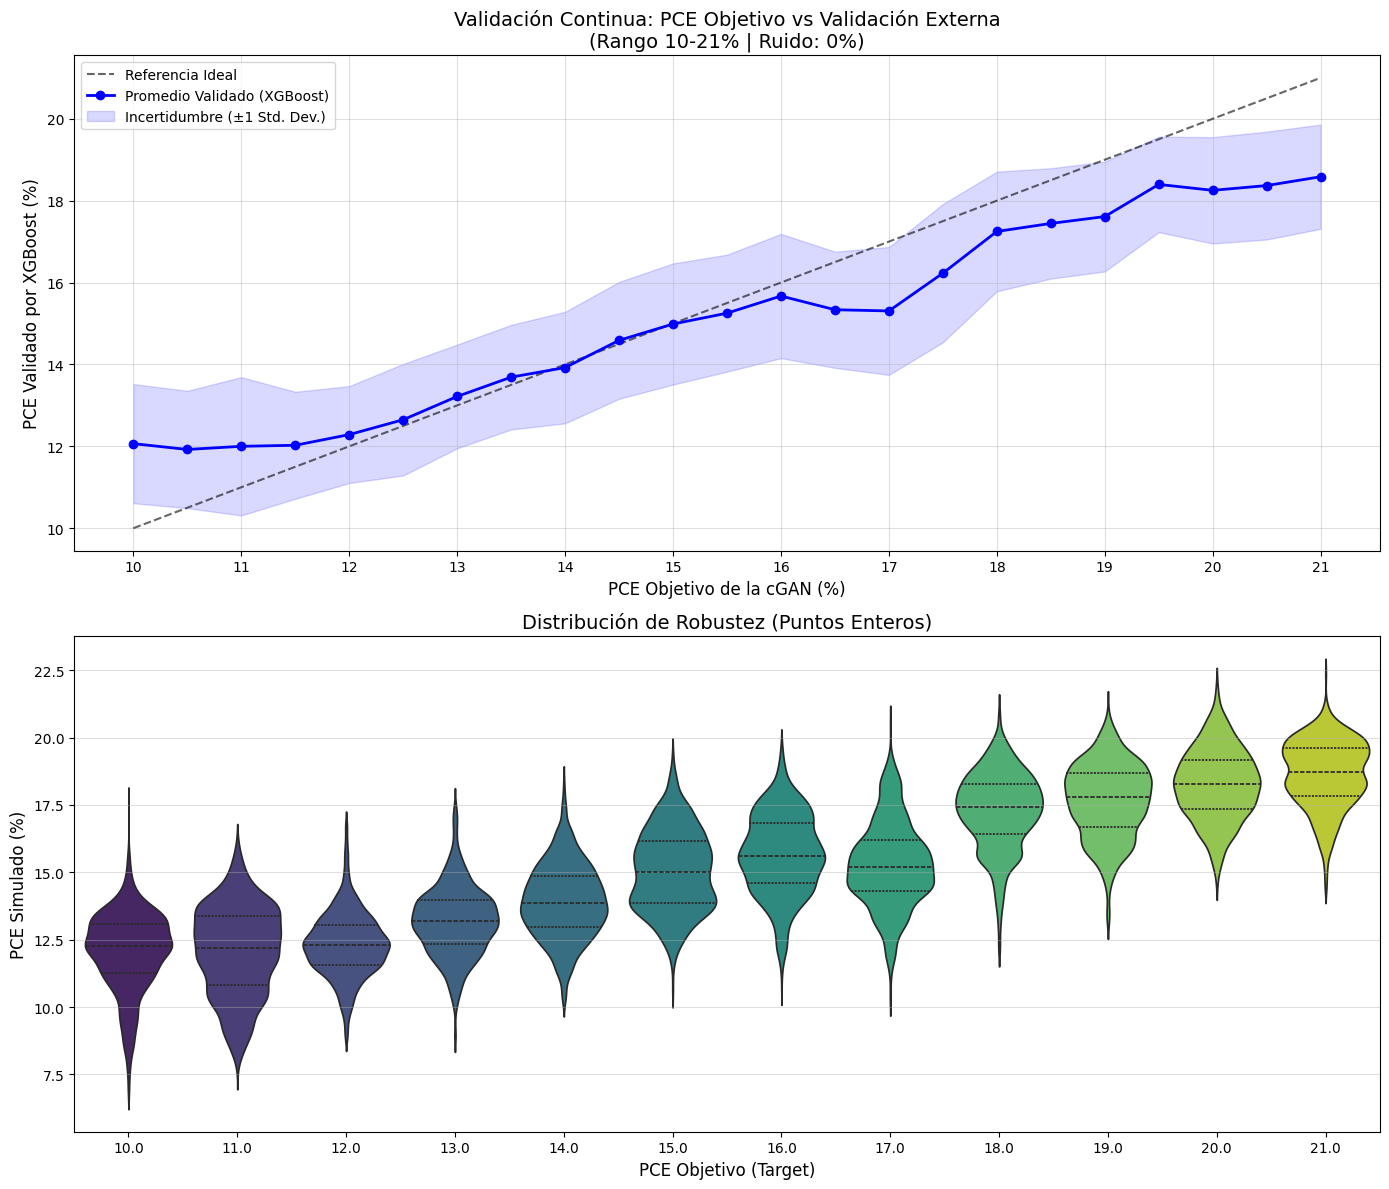


RESUMEN FINAL DE LA VALIDACIÓN CONTINUA
Error Absoluto Medio (MAE) Global: 0.9275%
Correlación (R) Target vs Predicción: 0.9880
✅ RESULTADO: EXCELENTE. La cGAN ha aprendido la tendencia física continua.


In [ ]:
# =============================================================================
# VALIDACIÓN DE ROBUSTEZ: MODELO PREDICTIVO (XGBOOST) VS GENERADOR (cGAN)
# VERSIÓN ACTUALIZADA: COMPATIBLE CON ZIP Y RANGO CONTINUO
# =============================================================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile  # Necesario para extraer los datos generados

# --- CONFIGURACIÓN ---
# Actualizamos el rango para que coincida con tu generación continua
# np.arange(inicio, fin, paso) -> Debe coincidir con cgan_generation_universal.py
TARGETS_PCE = np.arange(10.0, 21.0, 0.5)

N_SIMULATIONS = 1000     # Simulaciones por cada dato generado
NOISE_LEVEL = 0       # Nivel de ruido experimental (5%)
N_SAMPLES_PER_FILE = 1000 # Cantidad de muestras que generaste por archivo

# Nombre del archivo ZIP que contiene los datasets
ZIP_FILENAME = "datasets_generados_10_to_21.zip"

# Nombres de archivos y modelos
MODEL_PATH = 'Lab_Virtual_Universal.joblib'
SCALER_PATH = 'Scaler_Universal.joblib'

# =============================================================================
# 1. CARGA DE RECURSOS Y EXTRACCIÓN DE DATOS
# =============================================================================
print("Inicializando carga de modelos y herramientas...")

# A) Cargar Modelo Predictivo (Juez)
if os.path.exists(MODEL_PATH) and os.path.exists(SCALER_PATH):
    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
    print("✅ Modelo XGBoost y Scaler cargados exitosamente.")
else:
    raise FileNotFoundError("❌ Error crítico: No se encuentran los archivos .joblib (XGBoost). Súbelos primero.")

# B) Descomprimir Datos Generados
print(f"\nBusacando archivo de datos: {ZIP_FILENAME}...")
if os.path.exists(ZIP_FILENAME):
    print("📦 Descomprimiendo datasets generados...")
    with zipfile.ZipFile(ZIP_FILENAME, 'r') as zip_ref:
        zip_ref.extractall(".") # Extraer en la carpeta actual
    print("✅ Descompresión completada.")
else:
    # Si no está el zip, verificamos si los CSV ya están sueltos (por si acaso)
    sample_csv = f"Generated_PCE_{TARGETS_PCE[0]:.1f}_N_{N_SAMPLES_PER_FILE}.csv"
    if not os.path.exists(sample_csv):
        print(f"⚠️ No se encontró {ZIP_FILENAME} ni los archivos CSV extraídos.")
        print("Asegúrate de haber corrido el Script de Generación Universal primero.")

# Contenedores para resultados globales
results_summary = []
all_simulations_data = []

# =============================================================================
# 2. BUCLE DE VALIDACIÓN POR TARGET
# =============================================================================
print(f"\nIniciando Validación Montecarlo para {len(TARGETS_PCE)} objetivos continuos...")
print(f"Rango: {TARGETS_PCE[0]} -> {TARGETS_PCE[-1]}")
print("-" * 80)
print(f"{'Target (GAN)':<15} | {'Predicción Media (XGB)':<25} | {'Desviación Estándar':<20}")
print("-" * 80)

for target in TARGETS_PCE:
    # 2.1 Construir nombre del archivo (Formato del script de generación)
    filename = f"Generated_PCE_{target:.1f}_N_{N_SAMPLES_PER_FILE}.csv"

    if not os.path.exists(filename):
        # Es normal que falten algunos si el zip no cubrió todo, pero avisamos
        # print(f"   (Info: {filename} no encontrado, saltando...)")
        continue

    # 2.2 Cargar datos generados por la cGAN
    df_gen = pd.read_csv(filename)

    # 2.3 Preprocesamiento Adaptativo
    try:
        expected_features = scaler.n_features_in_
        total_columns = df_gen.shape[1]

        # Lógica de alineación de columnas (Features vs Target)
        # El archivo generado tiene una columna extra al final "PCE_Target" o "Target"

        # Caso A: El archivo tiene exactamente Features + 1 Target
        if total_columns == expected_features + 1:
            X_gen_base = df_gen.iloc[:, :-1].values

        # Caso B: El archivo tiene Metadata + Features + Target (Estructura antigua)
        elif total_columns >= expected_features + 5:
            X_gen_base = df_gen.iloc[:, 4:-1].values

        # Caso C: Busqueda por conteo desde el final
        else:
            start_col = total_columns - 1 - expected_features
            if start_col >= 0:
                X_gen_base = df_gen.iloc[:, start_col:-1].values
            else:
                # Si fallan las dimensiones, podría ser que el XGBoost fue entrenado con MENOS columnas
                # que la nueva GAN Universal. Esto es una alerta importante.
                print(f"⚠️ Error de dimensión en {target}: XGBoost espera {expected_features} cols, Dataset tiene {total_columns-1}.")
                continue

    except Exception as e:
        print(f"Error procesando estructura de columnas en {filename}: {e}")
        continue

    # 2.4 MONTECARLO VECTORIZADO
    n_features = X_gen_base.shape[1]

    # Repetimos cada muestra N_SIMULATIONS veces
    X_repeated = np.repeat(X_gen_base, N_SIMULATIONS, axis=0)

    # Generamos matriz de ruido normal
    noise_matrix = np.random.normal(0, 1, size=X_repeated.shape)

    # Aplicamos perturbación: X_new = X * (1 + noise * level)
    X_noisy = X_repeated * (1 + noise_matrix * NOISE_LEVEL)

    # 2.5 Escalar y Predecir
    X_noisy_scaled = scaler.transform(X_noisy)
    y_pred_noisy = model.predict(X_noisy_scaled)

    # 2.6 Calcular Estadísticas Descriptivas
    mean_pred = np.mean(y_pred_noisy)
    std_pred = np.std(y_pred_noisy)

    # Almacenar resumen estadístico
    results_summary.append({
        'Target_GAN': target,
        'Mean_XGB': mean_pred,
        'Std_XGB': std_pred,
        'Lower_CI': np.percentile(y_pred_noisy, 2.5),
        'Upper_CI': np.percentile(y_pred_noisy, 97.5)
    })

    # Almacenar muestra de datos para visualización (muestreo reducido para gráficos rápidos)
    sample_preds = np.random.choice(y_pred_noisy, size=2000, replace=False)
    for p in sample_preds:
        all_simulations_data.append({'Target': target, 'Prediccion': p}) # Target como numero para plot continuo

    print(f"{target:<15.1f} | {mean_pred:<25.4f} | {std_pred:<20.4f}")

# Convertir a DataFrame
df_results = pd.DataFrame(results_summary)
df_violin = pd.DataFrame(all_simulations_data)

if df_results.empty:
    print("❌ No se procesaron resultados. Verifica que el ZIP se haya descomprimido correctamente.")
else:
    # =============================================================================
    # 3. VISUALIZACIÓN DE RESULTADOS
    # =============================================================================
    plt.figure(figsize=(14, 12))

    # --- PANEL SUPERIOR: Correlación Lineal (Idealmente debe ser una recta) ---
    plt.subplot(2, 1, 1)
    # Línea ideal (Identidad)
    plt.plot(df_results['Target_GAN'], df_results['Target_GAN'], 'k--', label='Referencia Ideal', alpha=0.6)

    # Línea real (Predicción XGBoost)
    plt.plot(df_results['Target_GAN'], df_results['Mean_XGB'], 'b-o', label='Promedio Validado (XGBoost)', linewidth=2)

    # Intervalo de confianza
    plt.fill_between(df_results['Target_GAN'],
                     df_results['Mean_XGB'] - df_results['Std_XGB'],
                     df_results['Mean_XGB'] + df_results['Std_XGB'],
                     color='blue', alpha=0.15, label='Incertidumbre (±1 Std. Dev.)')

    plt.title(f'Validación Continua: PCE Objetivo vs Validación Externa\n(Rango 10-21% | Ruido: {NOISE_LEVEL*100}%)', fontsize=14)
    plt.ylabel('PCE Validado por XGBoost (%)', fontsize=12)
    plt.xlabel('PCE Objetivo de la cGAN (%)', fontsize=12)
    plt.xticks(np.arange(10, 22, 1)) # Eje X más limpio
    plt.legend()
    plt.grid(True, alpha=0.4)

    # --- PANEL INFERIOR: Distribución de Densidad (Violin Plot) ---
    plt.subplot(2, 1, 2)
    # Para el gráfico de violín, si hay demasiados puntos (ej. cada 0.1), se ve saturado.
    # Filtramos para mostrar solo enteros en el eje X del violin plot para limpieza visual
    df_violin_plot = df_violin[df_violin['Target'].apply(lambda x: x.is_integer())]

    sns.violinplot(x='Target', y='Prediccion', data=df_violin_plot, palette="viridis", inner="quartile")
    plt.title('Distribución de Robustez (Puntos Enteros)', fontsize=14)
    plt.ylabel('PCE Simulado (%)', fontsize=12)
    plt.xlabel('PCE Objetivo (Target)', fontsize=12)
    plt.grid(True, axis='y', alpha=0.4)

    plt.tight_layout()
    plt.show()

    # =============================================================================
    # 4. CONCLUSIONES DEL ANÁLISIS
    # =============================================================================
    print("\n" + "="*60)
    print("RESUMEN FINAL DE LA VALIDACIÓN CONTINUA")
    print("="*60)

    # Calcular error absoluto medio (MAE)
    mae_global = np.mean(np.abs(df_results['Target_GAN'] - df_results['Mean_XGB']))
    correlation = df_results['Target_GAN'].corr(df_results['Mean_XGB'])

    print(f"Error Absoluto Medio (MAE) Global: {mae_global:.4f}%")
    print(f"Correlación (R) Target vs Predicción: {correlation:.4f}")

    if mae_global < 1.0 and correlation > 0.9:
        print("✅ RESULTADO: EXCELENTE. La cGAN ha aprendido la tendencia física continua.")
    elif correlation > 0.8:
        print("⚠️ RESULTADO: BUENO PERO CON SESGO. Sigue la tendencia pero con offset.")
    else:
        print("❌ RESULTADO: FALLO EN TENDENCIA. La cGAN no responde linealmente al objetivo.")

# **ROBUSTNESS TESTING OF THE INVERSE DESIGN**
Noise ranging from 0 to 10% was introduced into the Monte Carlo simulation (N=1000 iterations per target) of the virtual laboratory.


⚙️ Inicializando recursos...

📥 Cargando datos base en memoria RAM...
✅ Datos cargados para 23 objetivos (Targets).

🚀 Iniciando prueba de estrés: 11 niveles de ruido...
-----------------------------------------------------------------
Nivel Ruido (%)      | MAE Global      | Correlación (R)
-----------------------------------------------------------------
0.0                  | 0.9564          | 0.9823         
1.0                  | 1.1020          | 0.9839         
2.0                  | 1.2230          | 0.9831         
3.0                  | 1.3330          | 0.9792         
4.0                  | 1.4003          | 0.9763         
5.0                  | 1.4448          | 0.9745         
6.0                  | 1.4892          | 0.9729         
7.0                  | 1.5264          | 0.9722         
8.0                  | 1.5631          | 0.9709         
9.0                  | 1.5982          | 0.9699         
10.0                 | 1.6328          | 0.9690         


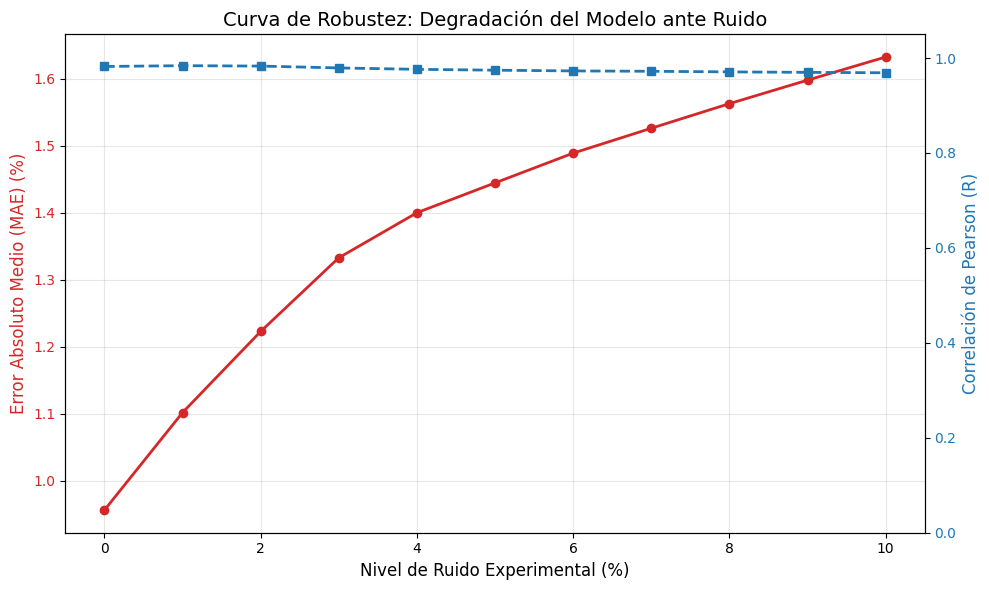


DIAGNÓSTICO DE ROBUSTEZ
MAE Inicial (0% Ruido): 0.9564
MAE Final (10% Ruido): 1.6328
Degradación: +0.6764 puntos de error.
✅ EL MODELO ES MUY ROBUSTO. El ruido afecta poco a la predicción.


In [ ]:
# =============================================================================
# PRUEBA DE ROBUSTEZ CIENTÍFICA: SENSIBILIDAD AL RUIDO (0% - 10%)
# =============================================================================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import os
import zipfile

# --- CONFIGURACIÓN ---
TARGETS_PCE = np.arange(10.0, 21.1, 0.5)
N_SAMPLES_PER_FILE = 1000
N_SIMULATIONS = 1000

# DEFINICIÓN DEL BARRIDO DE RUIDO
# De 0.00 (0%) a 0.10 (10%) en pasos de 0.01 (1%)
NOISE_LEVELS = np.arange(0.00, 0.11, 0.01)

ZIP_FILENAME = "datasets_generados_10_to_21.zip"
MODEL_PATH = 'Lab_Virtual_Universal.joblib'
SCALER_PATH = 'Scaler_Universal.joblib'

# =============================================================================
# 1. CARGA DE MODELOS Y EXTRACCIÓN
# =============================================================================
print("⚙️ Inicializando recursos...")

if os.path.exists(MODEL_PATH) and os.path.exists(SCALER_PATH):
    model = joblib.load(MODEL_PATH)
    scaler = joblib.load(SCALER_PATH)
else:
    raise FileNotFoundError("❌ Falta el modelo XGBoost o el Scaler.")

if not os.path.exists(f"Generated_PCE_{TARGETS_PCE[0]:.1f}_N_{N_SAMPLES_PER_FILE}.csv"):
    if os.path.exists(ZIP_FILENAME):
        print("📦 Descomprimiendo datos...")
        with zipfile.ZipFile(ZIP_FILENAME, 'r') as zip_ref:
            zip_ref.extractall(".")
    else:
        print("⚠️ No encuentro ZIP ni CSVs. Asegúrate de tener los datos.")

# =============================================================================
# 2. PRE-CARGA DE DATOS EN MEMORIA (OPTIMIZACIÓN)
# =============================================================================
# Para no leer el disco 11 veces (una por cada nivel de ruido),
# cargamos todos los matrices X base en un diccionario primero.
print(f"\n📥 Cargando datos base en memoria RAM...")

data_cache = {} # Diccionario {target: matriz_X}

for target in TARGETS_PCE:
    filename = f"Generated_PCE_{target:.1f}_N_{N_SAMPLES_PER_FILE}.csv"

    if not os.path.exists(filename):
        continue # Saltar si falta alguno

    df_gen = pd.read_csv(filename)

    # Lógica de columnas (Tu lógica original adaptada)
    expected_features = scaler.n_features_in_
    total_columns = df_gen.shape[1]

    try:
        if total_columns == expected_features + 1:
            X_base = df_gen.iloc[:, :-1].values
        elif total_columns >= expected_features + 5:
            X_base = df_gen.iloc[:, 4:-1].values
        else:
            start_col = total_columns - 1 - expected_features
            if start_col >= 0:
                X_base = df_gen.iloc[:, start_col:-1].values
            else:
                continue

        # Guardamos en caché
        data_cache[target] = X_base

    except Exception:
        continue

print(f"✅ Datos cargados para {len(data_cache)} objetivos (Targets).")

# =============================================================================
# 3. BUCLE DE ROBUSTEZ (SWEEP DE RUIDO)
# =============================================================================
print(f"\n🚀 Iniciando prueba de estrés: {len(NOISE_LEVELS)} niveles de ruido...")
print("-" * 65)
print(f"{'Nivel Ruido (%)':<20} | {'MAE Global':<15} | {'Correlación (R)':<15}")
print("-" * 65)

robustness_log = []

for noise in NOISE_LEVELS:

    # Listas temporales para este nivel de ruido específico
    targets_curr = []
    preds_curr = []

    for target, X_base in data_cache.items():
        # A) Vectorización Montecarlo
        # Repetimos X para simular variabilidad
        X_repeated = np.repeat(X_base, N_SIMULATIONS // 10, axis=0) # Optimización leve

        # B) Inyección de Ruido
        noise_matrix = np.random.normal(0, 1, size=X_repeated.shape)
        X_noisy = X_repeated * (1 + noise_matrix * noise)

        # C) Predicción
        X_scaled = scaler.transform(X_noisy)
        y_pred = model.predict(X_scaled)

        # Guardamos promedio
        targets_curr.append(target)
        preds_curr.append(np.mean(y_pred))

    # D) Calcular Métricas Globales para este nivel de ruido
    targets_arr = np.array(targets_curr)
    preds_arr = np.array(preds_curr)

    mae = np.mean(np.abs(targets_arr - preds_arr))
    corr = np.corrcoef(targets_arr, preds_arr)[0, 1]

    robustness_log.append({
        'Noise_Pct': noise * 100,
        'MAE': mae,
        'Correlation': corr
    })

    print(f"{noise*100:<20.1f} | {mae:<15.4f} | {corr:<15.4f}")

# =============================================================================
# 4. VISUALIZACIÓN DE LA CURVA DE DEGRADACIÓN
# =============================================================================
df_robustness = pd.DataFrame(robustness_log)

fig, ax1 = plt.subplots(figsize=(10, 6))

# Eje Y Izquierdo: MAE (Queremos que sea bajo)
color = 'tab:red'
ax1.set_xlabel('Nivel de Ruido Experimental (%)', fontsize=12)
ax1.set_ylabel('Error Absoluto Medio (MAE) (%)', color=color, fontsize=12)
ax1.plot(df_robustness['Noise_Pct'], df_robustness['MAE'], color=color, marker='o', label='MAE (Error)', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, alpha=0.3)

# Eje Y Derecho: Correlación (Queremos que sea alta)
ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('Correlación de Pearson (R)', color=color, fontsize=12)
ax2.plot(df_robustness['Noise_Pct'], df_robustness['Correlation'], color=color, marker='s', linestyle='--', label='Correlación', linewidth=2)
ax2.tick_params(axis='y', labelcolor=color)
# Fijar límites para correlación (idealmente cerca de 1)
ax2.set_ylim(0, 1.05)

plt.title('Curva de Robustez: Degradación del Modelo ante Ruido', fontsize=14)
fig.tight_layout()
plt.show()

# =============================================================================
# 5. CONCLUSIÓN AUTOMÁTICA
# =============================================================================
print("\n" + "="*60)
print("DIAGNÓSTICO DE ROBUSTEZ")
print("="*60)

mae_0 = df_robustness.iloc[0]['MAE']
mae_10 = df_robustness.iloc[-1]['MAE']
degradation = mae_10 - mae_0

print(f"MAE Inicial (0% Ruido): {mae_0:.4f}")
print(f"MAE Final (10% Ruido): {mae_10:.4f}")
print(f"Degradación: +{degradation:.4f} puntos de error.")

if degradation < 1.0:
    print("✅ EL MODELO ES MUY ROBUSTO. El ruido afecta poco a la predicción.")
elif degradation < 2.5:
    print("⚠️ EL MODELO ES SENSIBLE. El ruido degrada notablemente la precisión.")
else:
    print("❌ EL MODELO ES INESTABLE ante ruido alto.")